# AIRLINE DELAYS - VONESAT E LINJAVE AJRORE

**Punuan:** Blerina Tafaj
                                      
**Dataset:** DelayedFlights.csv (Kaggle, U.S. DOT, 2008)

---
### Çfarë bëjmë në këtë notebook:
1. Ngarkojmë dhe shikojmë dataset-in, kuptojmë strukturën dhe problemet.
2. Pastrojmë dataset-in dhe verifikojmë rezultatin.
3. Analizojmë 7 pyetje kërkimore me grafikë dhe nxjerrim përfundimet.




---
## Importet

Importojmë libraritë kryesore që do të përdorim gjatë punës.


In [1]:
# Importet kryesore për analizën e të dhënave
# pandas - libraria kryesore, tabela të dhënash (DataFrame)
import pandas as pd 
# numpy - veprime matematikore
import numpy as np
# matplotlib - krijimi i grafikëve
import matplotlib.pyplot as plt 
# seaborn - krijimi i grafikëve statistikorë 
import seaborn as sns         
# Path - rrugë skedarësh 
from pathlib import Path  
# Heqim paralajmërimet
import warnings          
warnings.filterwarnings("ignore")

# Stili standart i grafikëve 
sns.set_theme(style="whitegrid")

# Madhësia standarde e grafikëve
plt.rcParams["figure.figsize"] = (10, 6)

# Përcaktojmë rrugën e skedarit 
DATA_PATH = Path("DelayedFlightsRaw.csv")

# Kontrollojmë nëse skedari ekziston 
if DATA_PATH.exists():
    print(f"Skedari u gjet: {DATA_PATH.name}")
else:
    print(f"KUJDES! Skedari nuk u gjet në {DATA_PATH}")


Skedari u gjet: DelayedFlightsRaw.csv


---
## Funksionet e Pastrimit

Pastrimi organizohet si një seri funksionesh të pavarura, ku secila bën një punë të vetme. Çdo funksion merr një DataFrame dhe kthen një DataFrame të ri. `df.copy()` brenda funksionit siguron që origjinali të mos ndryshohet. Kjo metodë është zgjedhur për arsyet se:
- Mund të testojmë çdo funksion veç e veç
- I njëjti funksion mund të ripërdoret 

### Lista e funksioneve që do të ndërtojmë:

| Funksioni | Shpjegimi |
|-----------|-----------|
| `load_raw` | Lexon skedarin CSV dhe kthen DataFrame |
| `drop_unnecessary` | Heq kolonat e panevojshme |
| `fix_dtypes` | Optimizon tipet e të dhënave (float32, category, Int32) |
| `fix_dates` | Konverton orarin HHMM → datetime |
| `handle_outliers` | Kufizon vonesat ekstreme (cap = 600 min) |
| `drop_duplicates` | Heq rreshtat identikë |
| `handle_missing_data` | Plotësimi i të vlerave që mungojnë sipas fushës. |
| `discretize_delays` | Krijon `DelayCategory` me `pd.cut()` |


In [2]:
# load_raw - Lexon CSV-në dhe kthen DataFrame me emrat e pastruar të kolonave.
def load_raw(filepath, nrows=None):
    # Konvertojmë në Path nëse hyrja është string
    filepath = Path(filepath)

    # Leximi i CSV
    df = pd.read_csv(filepath, nrows=nrows)

    # Heqim hapësirat e tepërta nga emrat e kolonave
    df.columns = df.columns.str.strip()

    # Printojmë formën e dataset-it të ngarkuar
    print(f"   {len(df):,} rreshta, {df.shape[1]} kolona")
    return df


In [3]:
# drop_unnecessary - Heq kolonat që nuk na nevojiten për analizën
def drop_unnecessary(df):
    df = df.copy()

    # Lista e kolonave që do heqim
    #- Unnamed: 0 → indeks i dyfishtë 
    #- TailNum   → numri i regjistrit të avionit 
    #- FlightNum → numri i fluturimit 
    col_drop = ["Unnamed: 0", "TailNum", "FlightNum"]
    df = df.drop(columns=col_drop)

    print(f"U hoqën kolonat: {col_drop}")
    return df


In [4]:
# dix_dtypes - Konverton tipet e kolonave për të kursyer memorie, sepse dataseti ynë është goxha i madh.

# Metoda e ndjekur:
#- float64 → float32  (gjysma e memories, mjafton për vonesat)
#- kolonat me pak vlera unike → category (10-20x më e vogël)
#- kolonat Year/Month/Day → Int32 nullable 

def fix_dtypes(df):

    # float64 → float32
    floats = df.select_dtypes(include=["float64"]).columns
    df[floats] = df[floats].astype("float32")

    # kolonat me pak vlera unike → category
    for col in ["UniqueCarrier", "Origin", "Dest", "CancellationCode"]:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # kolonat Year/Month/Day → Int32 nullable 
    int_cols = ["Year", "Month", "DayofMonth", "DayOfWeek"]
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype("Int32")

    # Heqim hapësirat dhe i kthejmë në shkronja kapitale (uppercase)
    for col in ["Origin", "Dest"]:
        if col in df.columns:
            df[col] = df[col].str.strip().str.upper()

    # convert_dtypes() konverton kolonat në tipe më të mira automatikisht
    df = df.convert_dtypes()
    return df


In [5]:
#dates - Konverton kolonat e orës nga formati HHMM në objekte datetime.
def fix_dates(df):
    
    df = df.copy()

    # Krijojmë kolonën DATE duke bashkuar Year + Month + DayofMonth.
    # pd.to_datetime kërkon kolonat të quhen 'year'/'month'/'day' (me shkronja të vogla)
    df["DATE"] = pd.to_datetime(df[["Year", "Month", "DayofMonth"]].rename(
        columns={"Year": "year", "Month": "month", "DayofMonth": "day"}))

    # Kolonat e orës që duhet të konvertohen
    time_cols = ["DepTime", "CRSDepTime", "ArrTime", "CRSArrTime"]

    for col in time_cols:
        if col in df.columns:
            # 1435 // 100 = 14 (ora)
            hours = (df[col] // 100)
            # 1435 % 100 = 35 (minutat)
            minutes = (df[col] % 100)

            # Bashkojmë: DATA + orë + minuta → datetime i plotë
            df[f"{col}_dt"] = (df["DATE"]
                               + pd.to_timedelta(hours, unit="h")
                               + pd.to_timedelta(minutes, unit="m"))

            # Aty ku origjinali ishte NaN, vendos NaT
            df.loc[df[col].isnull(), f"{col}_dt"] = pd.NaT
    return df


In [6]:
# handle_outliners - Kufizon vonesat ekstreme në 600 minuta me .clip().
def handle_outliers(df, delay_cap=600.0):
   
    df = df.copy()

    # Kolonat e vonesave
    delay_cols = [
        "ArrDelay", "DepDelay", "CarrierDelay", "WeatherDelay",
        "NASDelay", "SecurityDelay", "LateAircraftDelay"
    ]

    for col in delay_cols:
        if col in df.columns:
            # Numërojmë sa vlera janë mbi limitin
            n_outliers = (df[col] > delay_cap).sum()

            if n_outliers > 0:
                # .clip(upper=600) vendos çdo vlerë > 600 në 600
                df[col] = df[col].clip(upper=delay_cap)
                print(f"  {col}: {n_outliers:,} vlera u kufizuan në {delay_cap} min")
    return df


In [7]:
# drop_duplicates - Heq rreshtat komplet identikë. Mban rreshtin e parë (keep='first') dhe fshin përsëritjet.
def drop_duplicates(df):
  
    df = df.copy()

    # Numri i rreshtave para heqjes
    n_before = len(df)
    df = df.drop_duplicates(keep="first")

    # Llogarisim sa u hoqën
    n_removed = n_before - len(df)

    if n_removed > 0:
        print(f"Duplikata të hequra: {n_removed:,} rreshta")
    else:
        print("Nuk u gjet asnjë duplikatë!")
    return df


In [8]:
# discretize_delays - Krijon kolonën DelayCategory me pd.cut() 
def discretize_delays(df):
    if "ArrDelay" in df.columns:
        # Kufijtë e grupeve
        bins = [-np.inf, 0, 15, 60, np.inf]
        labels = ["No Delay", "Small", "Medium", "Large"]

        # pd.cut() ndan vlerat sipas kufijve dhe u vendos etiketat
        df["DelayCategory"] = pd.cut(df["ArrDelay"], bins=bins, labels=labels)
    return df


###  Shënim mbi `handle_missing_data`:

Ky funksion është më kompleksi sepse trajton secilën kolonë me strategji të ndryshme. 


**Pse mbushim vonesat sipas shkakut me 0:**  
Bëmë këtë analizë para se të zgjidhnim strategjinë:
- 689,270 rreshta kanë `CarrierDelay/WeatherDelay/...` të gjitha NaN njëkohësisht
- Te këto rreshta, `ArrDelay.max() = 14 min` (vonesë e parëndësishme)
- **Përfundimi:** kur këto kolona janë NaN, do të thotë se "ai shkak nuk kontribuoi", pra NaN = 0 minuta vonesë nga ky shkak (jo informacion i panjohur)

**Pse `transform('median')` për CRSElapsedTime:**  
Kohëzgjatja varet nga rruga (Origin → Dest). Pra mediana e rrugës është më e saktë se mediana globale. 

**Pse TaxiOut mbushet me medianën globale:**
Ndryshe nga vonesat që janë specifike për çdo fluturim, koha e taksimit (TaxiOut) varet nga trafiku në aeroport në një moment të caktuar.

**Pse CancellationCode plotësohet me 'N' (No cancellation):**
Kjo kolonë tregon shkakun e anulimit (p.sh., 'A' për Carrier, 'B' për Weather). Kur vlera është NaN, ky nuk është një rast i humbur për shkak të gabimit të sistemit, por një informacion kategorik.

**Pse përdorim medianën për ArrTime, AirTime, etj. (për fluturimet jo të anuluara):**
Përdorim medianën për këto kolona sepse ajo siguron një vlerë përfaqësuese dhe të paanshme për fluturimet, duke shmangur ndikimin e vlerave ekstreme në dataset.


In [9]:
def handle_missing_data(df):
    
    df = df.copy()

    #1) Vonesat sipas shkakut 
    delay_fill = {
        "CarrierDelay": 0, "WeatherDelay": 0, "NASDelay": 0,
        "SecurityDelay": 0, "LateAircraftDelay": 0
    }
    # fillna me dict mbush secilën kolonë me vlerën e vet
    df.fillna(value=delay_fill, inplace=True)

    # 2) TaxiOut 
    # Mbushim me medianen globale 
    if "TaxiOut" in df.columns:
        taxi_median = round(df["TaxiOut"].median())
        df["TaxiOut"] = df["TaxiOut"].fillna(taxi_median)

    # 3) CRSElapsedTime 
    # Metoda me dy nivele:
    # a) Mediana e rrugës (Origin, Dest) 
    # b) Mediana globale si rezervë për rrugët e reja
    if "CRSElapsedTime" in df.columns:
        #transform('median') kthen medianen e grupit te çdo rresht origjinal
        group_medians = df.groupby(["Origin", "Dest"])["CRSElapsedTime"].transform("median")
        df["CRSElapsedTime"] = df["CRSElapsedTime"].fillna(group_medians.round())

        #Për ato që ende kanë NaN (rrugë krejt të reja), përdorim globalen
        global_median = round(df["CRSElapsedTime"].median())
        df["CRSElapsedTime"] = df["CRSElapsedTime"].fillna(global_median)

    # 4) CancellationCode 
    # NaN = fluturimi NUK u anulua → vendosim 'N' (No cancellation)
    if "CancellationCode" in df.columns:
        df["CancellationCode"] = df["CancellationCode"].fillna("N")

    # 5) Kolonat e tjera (vetëm për fluturimet jo të anuluara) 
    # Fluturimet e anuluara natyrshëm nuk i kanë këto vlera, pra i lëmë NaN
    cols_to_fill = ["ArrTime", "ActualElapsedTime", "AirTime", "ArrDelay", "TaxiIn"]
    for col in cols_to_fill:
        if col in df.columns:
            median_val = round(df[col].median())
            # Maska: kolona është NaN DHE fluturimi nuk është anuluar
            mask = (df[col].isnull()) & (df["Cancelled"] == 0)
            df.loc[mask, col] = median_val

    return df.convert_dtypes()

# Konfirmim që të gjitha funksionet u ngarkuan me sukses
print("Të gjitha funksionet e pastrimit u ngarkuan me sukses.")

Të gjitha funksionet e pastrimit u ngarkuan me sukses.


---
## 1.1 Ngarkimi dhe Pasqyra e Përgjithshme

Në këtë fazë të parë, fokusi është te kuptimi i strukturës dhe përmbajtjes së datasetit tonë. 

Kryejmë analizat e mëposhtme:
- Informacioni **(info)**: Kontrollohen tipet e të dhënave (integers, floats, objects) dhe përdorimi i memories.
- Statistikat Përmbledhëse **(describe)**: Llogariten vlerat mesatare, devijimi standard, minimumi, maksimumi dhe kuartilet për kolonat numerike. Kjo na ndihmon të shohim shpërndarjen e të dhënave dhe praninë e mundshme të vlerave ekstreme (outliers).

### Përshkrimi i kolonave

| Kolona | Tipi | Përshkrimi |
|--------|------|------------|
| `Year` | int | Viti i fluturimit (2008) |
| `Month` | int | Muaji (1–12) |
| `DayofMonth` | int | Dita e muajit (1–31) |
| `DayOfWeek` | int | Dita e javës (1=E Hënë, 7=E Diel) |
| `DepTime` | float | Ora reale e nisjes, format HHMM (p.sh. 1435 = 14:35) |
| `CRSDepTime` | int | Ora e planifikuar e nisjes, format HHMM |
| `ArrTime` | float | Ora reale e mbërritjes, format HHMM |
| `CRSArrTime` | int | Ora e planifikuar e mbërritjes, format HHMM |
| `UniqueCarrier` | str | Kodi i kompanisë ajrore (p.sh. WN = Southwest) |
| `FlightNum` | int | Numri i fluturimit |
| `TailNum` | str | Numri i regjistrimit të avionit |
| `ActualElapsedTime` | float | Kohëzgjatja reale e fluturimit (minuta) |
| `CRSElapsedTime` | float | Kohëzgjatja e planifikuar e fluturimit (minuta) |
| `AirTime` | float | Koha në ajër, pa taxi (minuta) |
| `ArrDelay` | float | Vonesë mbërritjeje në minuta (negative = herët) |
| `DepDelay` | float | Vonesë nisje në minuta (negative = herët) |
| `Origin` | str | Kodi i aeroportit të nisjes (p.sh. IAD, JFK) |
| `Dest` | str | Kodi i aeroportit të destinacionit |
| `Distance` | int | Distanca e fluturimit (milje) |
| `TaxiIn` | float | Koha nga ulja deri te porta (minuta) |
| `TaxiOut` | float | Koha nga porta deri te ngritja (minuta) |
| `Cancelled` | int | 1 = u anulua, 0 = nuk u anulua |
| `CancellationCode` | str | Shkaku i anulimit: A=Carrier, B=Mot, C=NAS, D=Siguri |
| `Diverted` | int | 1 = u ridrejtua në aeroport tjetër, 0 = jo |
| `CarrierDelay` | float | Minuta vonesë për shkak të kompanisë ajrore |
| `WeatherDelay` | float | Minuta vonesë për shkak të motit |
| `NASDelay` | float | Minuta vonesë për shkak të sistemit kombëtar të ajrit |
| `SecurityDelay` | float | Minuta vonesë për shkak të sigurisë |
| `LateAircraftDelay` | float | Minuta vonesë sepse avioni erdhi me vonesë nga fluturimi paraardhës |


In [10]:
df_clean = load_raw(DATA_PATH, nrows=None)

# Forma: numri i rreshtave dhe kolonave
print(f"Forma e dataframe: {df_clean.shape[0]:,} rreshta × {df_clean.shape[1]} kolona")
print()

# Emrat e kolonave në formë liste
print("Kolonat:", df_clean.columns.tolist())


   1,936,758 rreshta, 30 kolona
Forma e dataframe: 1,936,758 rreshta × 30 kolona

Kolonat: ['Unnamed: 0', 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']


In [11]:
# .info() tregon tipin e të dhënave dhe sa vlera ka për çdo kolonë
print("Informacione rreth datasetit:")
df_clean.info()
print()

# .describe() jep statistikat bazë për kolonat numerike
# count, mean, std, min, 25%, 50% (mediana), 75%, max
print("Statistika bazë:")
df_clean.describe()

Informacione rreth datasetit:
<class 'pandas.DataFrame'>
RangeIndex: 1936758 entries, 0 to 1936757
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   Year               int64  
 2   Month              int64  
 3   DayofMonth         int64  
 4   DayOfWeek          int64  
 5   DepTime            float64
 6   CRSDepTime         int64  
 7   ArrTime            float64
 8   CRSArrTime         int64  
 9   UniqueCarrier      str    
 10  FlightNum          int64  
 11  TailNum            str    
 12  ActualElapsedTime  float64
 13  CRSElapsedTime     float64
 14  AirTime            float64
 15  ArrDelay           float64
 16  DepDelay           float64
 17  Origin             str    
 18  Dest               str    
 19  Distance           int64  
 20  TaxiIn             float64
 21  TaxiOut            float64
 22  Cancelled          int64  
 23  CancellationCode   str    
 24  Diverted           int64  
 25 

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,FlightNum,...,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,1.936758e+06,1936758.0,1.936758e+06,1.936758e+06,1.936758e+06,1.936758e+06,1.936758e+06,1.929648e+06,1.936758e+06,1.936758e+06,...,1.936758e+06,1.929648e+06,1.936303e+06,1.936758e+06,1.936758e+06,1.247488e+06,1.247488e+06,1.247488e+06,1.247488e+06,1.247488e+06
mean,3.341651e+06,2008.0,6.111106e+00,1.575347e+01,3.984827e+00,1.518534e+03,1.467473e+03,1.610141e+03,1.634225e+03,2.184263e+03,...,7.656862e+02,6.812975e+00,1.823220e+01,3.268348e-04,4.003598e-03,1.917940e+01,3.703571e+00,1.502164e+01,9.013714e-02,2.529647e+01
std,2.066065e+06,0.0,3.482546e+00,8.776272e+00,1.995966e+00,4.504853e+02,4.247668e+02,5.481781e+02,4.646347e+02,1.944702e+03,...,5.744797e+02,5.273595e+00,1.433853e+01,1.807562e-02,6.314722e-02,4.354621e+01,2.149290e+01,3.383305e+01,2.022714e+00,4.205486e+01
min,0.000000e+00,2008.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.517452e+06,2008.0,3.000000e+00,8.000000e+00,2.000000e+00,1.203000e+03,1.135000e+03,1.316000e+03,1.325000e+03,6.100000e+02,...,3.380000e+02,4.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.242558e+06,2008.0,6.000000e+00,1.600000e+01,4.000000e+00,1.545000e+03,1.510000e+03,1.715000e+03,1.705000e+03,1.543000e+03,...,6.060000e+02,6.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,8.000000e+00
75%,4.972467e+06,2008.0,9.000000e+00,2.300000e+01,6.000000e+00,1.900000e+03,1.815000e+03,2.030000e+03,2.014000e+03,3.422000e+03,...,9.980000e+02,8.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,2.100000e+01,0.000000e+00,1.500000e+01,0.000000e+00,3.300000e+01
max,7.009727e+06,2008.0,1.200000e+01,3.100000e+01,7.000000e+00,2.400000e+03,2.359000e+03,2.400000e+03,2.400000e+03,9.742000e+03,...,4.962000e+03,2.400000e+02,4.220000e+02,1.000000e+00,1.000000e+00,2.436000e+03,1.352000e+03,1.357000e+03,3.920000e+02,1.316000e+03


---
## 1.2 Analiza e Vlerave Që Mungojnë Para Pastrimit

Para se të mbushim/heqim vlerat, duhet të kuptojmë **pse** mungojnë.

Vlerat që mungojnë ndahen në tri lloje ():

- **MCAR** (Mungesë Plotësisht Rastësore): pa lidhje me të dhëna të tjera
- **MAR** (Mungesë Rastësore): mungesa lidhet me variabla të tjera
- **MNAR** (Mungesë Jo-Rastësore): vetë mungesa mbart informacion




In [12]:
# Llogarisim vlerat që mungojnë  për kolonë
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({
    "Mungojne": missing,
    "%": missing_pct
}).query("Mungojne > 0").sort_values("%", ascending=False)
#.query("Mungojne > 0") mban vetëm rreshtat me të paktën 1 NaN

missing_df


,Mungojne,%
LateAircraftDelay,689270,35.59
WeatherDelay,689270,35.59
NASDelay,689270,35.59
SecurityDelay,689270,35.59
CarrierDelay,689270,35.59
ActualElapsedTime,8387,0.43
ArrDelay,8387,0.43
AirTime,8387,0.43
ArrTime,7110,0.37
TaxiIn,7110,0.37


---
## 1.3 Analiza e Vlerave të Duplikuara, Kategorike dhe Formateve të Orës

Kontrolle të tjera:

- **Duplikatat:** Rreshtat plotësisht identikë çrregullojnë statistikat, ndaj duhen hequr.
- **Kolonat kategorike:** Shohim sa vlera unike kanë (për t'i bërë `category`).
- **Formati HHMM:** Kolona `DepTime` e ruan orën në format HHMM, por mund të përmbajë pasaktësi.


In [13]:
# Duplikatat 
print("Analiza e vlerave të duplikuara")
duplicates = df_clean.duplicated().sum()
print(f"Numri i rreshtave duplikatë: {duplicates}\n")

# Nëse ka duplikata, shfaqim përqindjen
if duplicates > 0:
    print(f"Përqindja e duplikatave: {(duplicates / len(df_clean) * 100):.2f}%\n")

# Vlerat kategorike 
print("Analiza e vlerave kategorike")
cat_cols = ["UniqueCarrier", "Origin", "Dest", "CancellationCode"]
for col in cat_cols:
    if col in df_clean.columns:
        #.nunique() = numri i vlerave unike
        print(f"{col}: {df_clean[col].nunique()} vlera unike\n")

# Formati i orës 
print("Analiza e formateve të orës")
# Minutat duhen të jenë <= 59. % 100 jep dy shifrat e fundit (minutat)
minutes_check = df_clean[df_clean["DepTime"] % 100 > 59]
print(f"Rreshta me minuta të pasakta: {len(minutes_check)}")

# 2400 është e gabuar (duhet të jetë 0000)
print(f"Rreshta me vlerën 2400: {(df_clean['DepTime'] == 2400).sum()}")


Analiza e vlerave të duplikuara
Numri i rreshtave duplikatë: 0

Analiza e vlerave kategorike
UniqueCarrier: 20 vlera unike

Origin: 303 vlera unike

Dest: 304 vlera unike

CancellationCode: 4 vlera unike

Analiza e formateve të orës
Rreshta me minuta të pasakta: 0
Rreshta me vlerën 2400: 321


---
## 1.4 Analiza e Vlerave Ekstreme

Vlerat ekstreme (outliers) mund të deformojnë mesataret dhe grafikët. 
Strategjia jonë : **Capping/Clipping** me `.clip()`.

Do të kufizojmë çdo vonesë mbi 600 minuta (10 orë) në 600. Nuk heqim rreshta, vetëm zvogëlojmë vlerat ekstreme.


In [14]:
print("Vlerat maksimale para pastrimit:")
print(df_clean[["ArrDelay", "DepDelay"]].max())


Vlerat maksimale para pastrimit:
ArrDelay    2461.0
DepDelay    2467.0
dtype: float64


---
## 1.5 Ekzekutimi i Pastrimit

Tani aplikojmë funksionet e pastrimit njëra pas tjetrës te gjithë dataset-i. 
Rezultati i njërit funksion bëhet hyrje për tjetrin (pattern: **pipeline**).

**Renditja e hapave:**

1. `drop_unnecessary` — Heq kolonat e parëndsishme
2. `fix_dtypes` — Optimizon tipet e të dhënave  
3. `fix_dates` — HHMM → datetime  
4. `handle_outliers` — Cap @ 600 min  
5. `drop_duplicates` — Heq rreshtat identikë  
6. `handle_missing_data` — Mbush vlerat null  
7. `discretize_delays` — Krijon `DelayCategory`


In [15]:
df_clean = drop_unnecessary(df_clean)      
df_clean = fix_dtypes(df_clean)            
df_clean = fix_dates(df_clean)            
df_clean = handle_outliers(df_clean)      
df_clean = drop_duplicates(df_clean)       
df_clean = handle_missing_data(df_clean)   
df_clean = discretize_delays(df_clean)    

# Ruajmë rezultatin në format Parquet 
out = "DelayedFlightsClean.parquet"
df_clean.to_parquet(out, index=False)
print(f"Dataset i pastruar u ruajt: {out}")

print("\nPASTRIMI PËRFUNDOI")


U hoqën kolonat: ['Unnamed: 0', 'TailNum', 'FlightNum']
  ArrDelay: 943 vlera u kufizuan në 600.0 min
  DepDelay: 931 vlera u kufizuan në 600.0 min
  CarrierDelay: 653 vlera u kufizuan në 600.0 min
  WeatherDelay: 92 vlera u kufizuan në 600.0 min
  NASDelay: 48 vlera u kufizuan në 600.0 min
  LateAircraftDelay: 46 vlera u kufizuan në 600.0 min
Duplikata të hequra: 2 rreshta
Dataset i pastruar u ruajt: DelayedFlightsClean.parquet

PASTRIMI PËRFUNDOI


---
## 1.6 Verifikimi i Rezultatit

Kontrollojmë që pastrimi funksionoi siç pritej.


In [16]:
# Forma përfundimtare
print("FORMA")
print(f"Rreshta: {df_clean.shape[0]:,}")
print(f"Kolona : {df_clean.shape[1]}")

print()
print("VLERAT QE MUNGOJNE PAS PASTRIMIT")
# Vetëm kolonat që ende kanë NaN (duhet të jenë vetëm nga fluturimet e anuluara)
still_missing = df_clean.isnull().sum()
still_missing = still_missing[still_missing > 0]

if len(still_missing) == 0:
    print("Asnjë kolonë me NaN të papritur")
else:
    print(still_missing)
    print("(Këto janë NaN të pritshme nga fluturimet e anuluara)")

print()
# Tipet e të dhënave pas optimizimit (duhen të jenë float32, category, Int32, etj.)
print("TIPET E TË DHËNAVE")
print(df_clean.dtypes)  

print()
# Statistika bazë për kolonat e vonesave
print("STATISTIKA BAZË")
df_clean[["ArrDelay", "DepDelay", "CarrierDelay", "WeatherDelay",
          "NASDelay", "SecurityDelay", "LateAircraftDelay"]].describe().round(2)


print()
# Verifikimi per vlerat ekstreme
print("Max ArrDelay:", df_clean["ArrDelay"].max())
print("Max DepDelay:", df_clean["DepDelay"].max())
print("Pritet: ≤ 600.0 ")

FORMA
Rreshta: 1,936,756
Kolona : 33

VLERAT QE MUNGOJNE PAS PASTRIMIT
ArrTime               633
ActualElapsedTime     633
AirTime               633
ArrDelay              633
TaxiIn                633
ArrTime_dt           7110
DelayCategory         633
dtype: int64
(Këto janë NaN të pritshme nga fluturimet e anuluara)

TIPET E TË DHËNAVE
Year                          Int32
Month                         Int32
DayofMonth                    Int32
DayOfWeek                     Int32
DepTime                       Int64
CRSDepTime                    Int64
ArrTime                       Int64
CRSArrTime                    Int64
UniqueCarrier              category
ActualElapsedTime             Int64
CRSElapsedTime                Int64
AirTime                       Int64
ArrDelay                      Int64
DepDelay                      Int64
Origin                       string
Dest                         string
Distance                      Int64
TaxiIn                        Int64
TaxiOut     

---
## 1.7 Përmbledhje e pastrimit

| Hapi | Çfarë bëmë | Pse |
|------|-----------|-----|
| `drop_unnecessary` | Hoqëm `Unnamed: 0`, `TailNum`, `FlightNum` | Detaje të panevojshme |
| `fix_dtypes` |Përdorëm category dhe llojet nullable Int64 |    Optimizimi i memories (Extension Types) dhe shmangia e float-eve të padëshiruara. |
| `handle_missing` |Plotësuam me 0 dhe medianë sipas logjikës | Për interpretime të sakta |
| `fix_dates` |Konvertuam HHMM në objekte datetime vektoriale | Format i llogaritshëm |
| `handle_outliers` | Cap vonosat > 600 min | Stabilizon datasetin |
| `discretize_delays` | Krijimi i DelayCategory përmes pd.cut() |   Transformimi i variablave numerike në grupe logjike për interpretim më të lehtë  |

**Dataset i pastruar u ruajt:** `DelayedFlightsClean.parquet` 


---
## 2. Pyetjet Kërkimore

Tani që dataset-i është i pastër, i përgjigjemi 7 pyetjeve. Çdo pyetje ka:
- Motivimin (pse e zgjodhëm)
- Bazën teorike
- Metodologjinë
- Grafikun me kod të komentuar
- Interpretimin


---
### P1. Cilat kompani ajrore kanë vonesat mesatare më të larta, dhe si ndryshon kjo sipas ditës së javës?

**Pse e zgjodhëm?**  
Vonesat ajrore pasqyrojnë vendime operacionale, kapacitet flote dhe menaxhim orari 
që ndryshojnë nga kompania në kompani. Dita e javës shton një dimension të rëndësishëm: 
ditët e pikut (E Premte, E Hënë) kanë ngarkesë më të lartë.

**Baza teorike:**  
Teoria e *congestion pricing* sugjeron që vonesat rriten **jo linearisht** me ngarkesën. 
Kur kapaciteti i afrohet limitit, edhe një vonesë e vogël fillestare amplifikohet. 
Analiza `UniqueCarrier × DayOfWeek` na lejon të dallojmë vonesa strukturore (problem flote) 
nga vonesa të përqendruara në ditë specifike (problem kapaciteti).

**Metodologjia:** Pivot table `UniqueCarrier × DayOfWeek` me `mean(ArrDelay)` → heatmap.


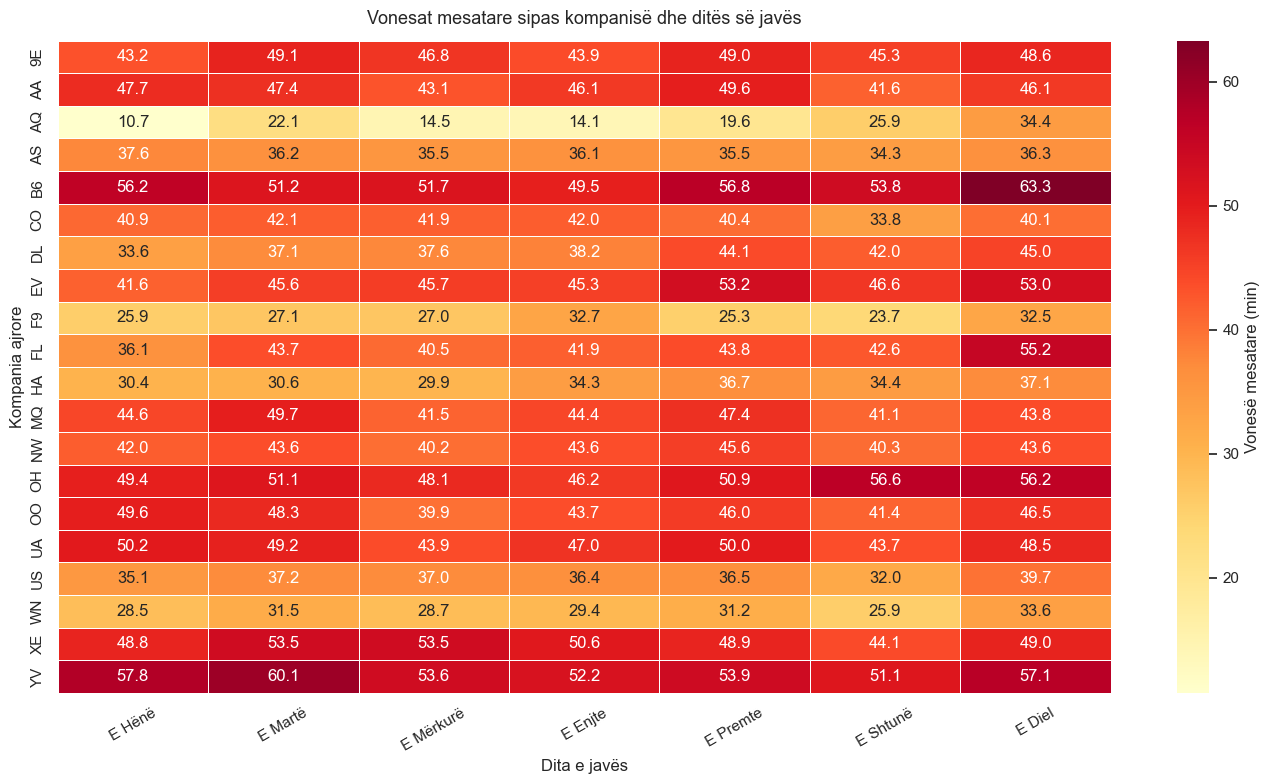

In [17]:
# Fjalori i emrave të ditëve të javës në shqip 
day_labels = {1: "E Hënë", 2: "E Martë", 3: "E Mërkurë",
              4: "E Enjte", 5: "E Premte", 6: "E Shtunë", 7: "E Diel"}

# Pipeline i të dhënave për heatmap:
#1) groupby — grupojmë sipas (kompani, ditë)
#2) ['ArrDelay'].mean() — llogarisim mesataren e ArrDelay për çdo grup
#3) .round(1) — rrumbullakim me një decimal
#4) .reset_index() — kthen MultiIndex në kolona normale
#5) .pivot(...) — kthen të dhënat në formë matrice (rreshta×kolona)
#6) .rename(columns=day_labels) — riemërton kolonat numerike në emra shqip
#7) .astype(float) + .fillna(0) — pastron tipet dhe mbush NaN
pivot = (df_clean
         .groupby(["UniqueCarrier", "DayOfWeek"])["ArrDelay"]
         .mean()
         .round(1)
         .reset_index()
         .pivot(index="UniqueCarrier", columns="DayOfWeek", values="ArrDelay")
         .rename(columns=day_labels)
         .astype(float)
         .fillna(0))

# Krijojmë figurën 
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, ax=ax,
            cbar_kws={"label": "Vonesë mesatare (min)"})

# Personalizimi i titullit dhe etiketave të boshteve (nga ax, jo plt)
ax.set_title("Vonesat mesatare sipas kompanisë dhe ditës së javës", fontsize=13, pad=12)
ax.set_xlabel("Dita e javës")
ax.set_ylabel("Kompania ajrore")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("p1_heatmap_carriers.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretimi:** Vonesat **nuk** shpërndahen uniformisht. **JetBlue (B6), YV dhe XE** 
kanë vonesa sistematike >50 min, ndërsa **Aloha (AQ)** është më e disiplinuar. 
**E Premtja & E Diela** rezultojnë ditët më kaotike.


---
### P2. Cili është kontributi i secilit shkak në vonesat e mëdha (>60 min), dhe cilat aeroporte janë burimet kryesore?

**Pse e zgjodhëm?**  
Identifikimi i shkaqeve rrënjë (*root cause analysis*) është hapi i parë për ndërhyrje korrigjuese. 
Nëse dominon `WeatherDelay`, zgjidhja është operacionale; nëse dominon `CarrierDelay`, 
zgjidhja është strukturore (menaxhim flote, rotacion ekuipazhi). 
Fokusi te vonesat >60 min është i qëllimshëm, pasi këto shkaktojnë efekt zinxhir.

**Baza teorike:**  
Sipas studimeve të FAA, ~75% e vonesave të mëdha kanë shkaqe të kontrollueshme nga operatorët 
(kompania ose NAS), ndërsa vetëm ~10-15% kanë shkak motin.

**Metodologjia:** Groupby `Origin` + sum për 4 komponentët → stacked bar chart + pie chart.


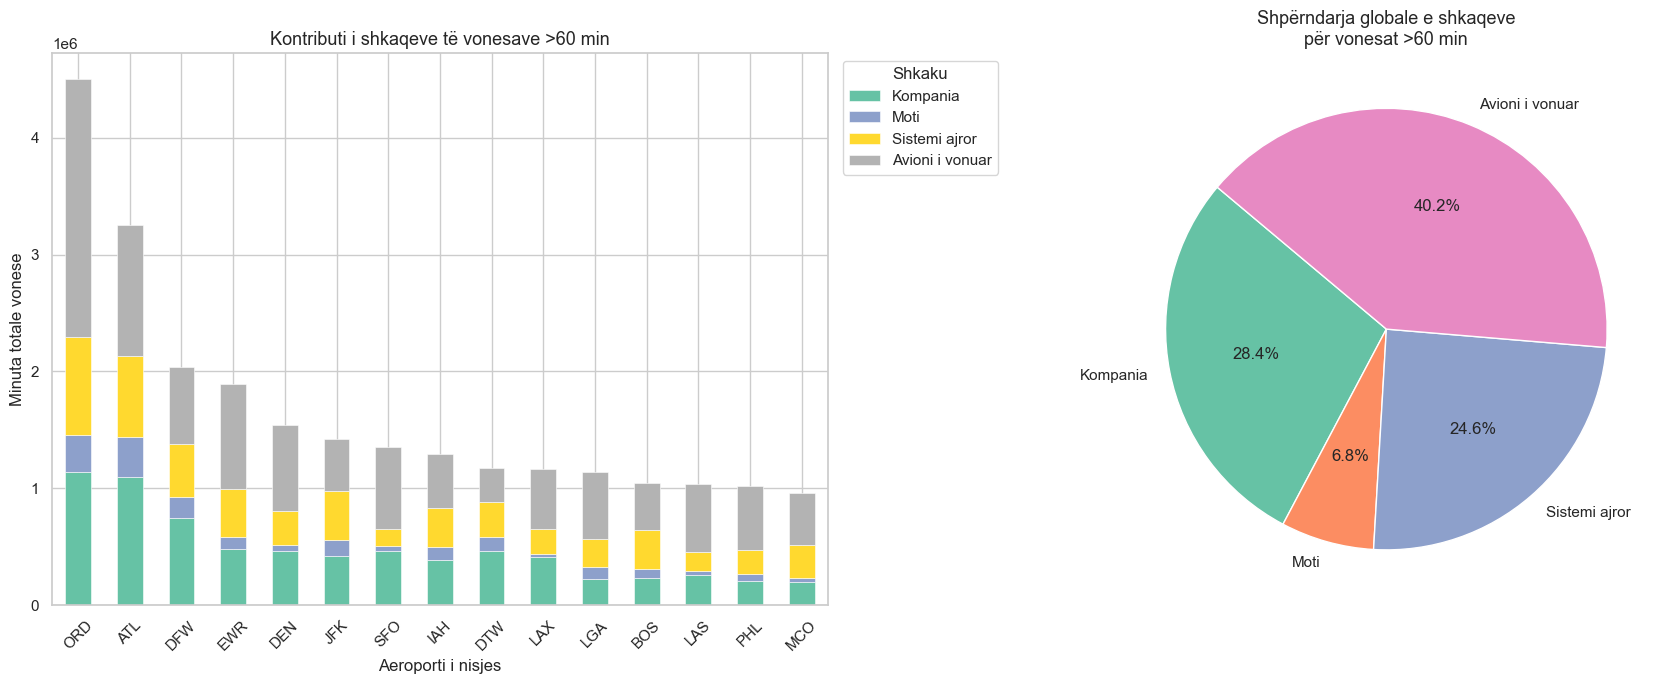

In [18]:
# Shkaqet e vonesave dhe etiketat shqip
delay_causes = ["CarrierDelay", "WeatherDelay", "NASDelay", "LateAircraftDelay"]
cause_labels = ["Kompania", "Moti", "Sistemi ajror", "Avioni i vonuar"]

# Filtrojmë vetëm fluturimet me vonesë >60 min
big_delays = df_clean[df_clean["ArrDelay"] > 60].copy()

# Pipeline për agregim:
#1) groupby("Origin") — për çdo aeroport
#2) [delay_causes].sum() — shumën e secilit shkak
#3) .assign(Total=...) — shton kolonën Total = shuma e të katërve
#4) .sort_values("Total", ascending=False) — më të mëdhatë sipër
by_origin = (big_delays.groupby("Origin")[delay_causes]
             .sum()
             .assign(Total=lambda x: x.sum(axis=1))
             .sort_values("Total", ascending=False))

# Marrim 15 aeroportet me vonesat më të mëdha, vetëm kolonat e shkaqeve
top15 = by_origin.head(15)[delay_causes]
top15.columns = cause_labels  

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafiku 1: Stacked bar 
top15.plot(kind="bar", stacked=True, ax=axes[0],
           colormap="Set2", edgecolor="white", linewidth=0.4)
axes[0].set_title("Kontributi i shkaqeve të vonesave >60 min", fontsize=13)
axes[0].set_xlabel("Aeroporti i nisjes")
axes[0].set_ylabel("Minuta totale vonese")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Shkaku", bbox_to_anchor=(1.01, 1), loc="upper left")

#Grafiku 2: Pie chart globale 
global_causes = big_delays[delay_causes].sum()
global_causes.index = cause_labels

axes[1].pie(global_causes, labels=cause_labels, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("Set2", 4))
axes[1].set_title("Shpërndarja globale e shkaqeve\npër vonesat >60 min", fontsize=13)

plt.tight_layout()
plt.savefig("p2_delay_causes.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretimi:** **40%** e vonesave të mëdha vijnë nga avioni paraardhës (efekti zinxhir), 
**28%** nga vetë kompania, vetëm **~7%** nga moti. **ORD & ATL** janë burimet kryesore.


---
### P3. A vërtetohet efekti 'zinxhir'? `LateAircraftDelay` → `ArrDelay`

**Pse e zgjodhëm?**  
Efekti zinxhir (*propagation delay*) është fenomeni më i dëmshëm në aviacionin komercial. 
Kur një avion mbërrin me vonesë, fluturimi pasardhës i të njëjtit avion vonohet automatikisht.

**Baza teorike:**  
Kolona `LateAircraftDelay` mat pikërisht këtë: minutat e vonesës nga avioni paraardhës. 
Korrelacion i lartë midis `LateAircraftDelay` dhe `ArrDelay` konfirmon se vonesa "udhëton".

**Metodologjia:** Scatter plot + vijë regresioni me `sns.regplot`.


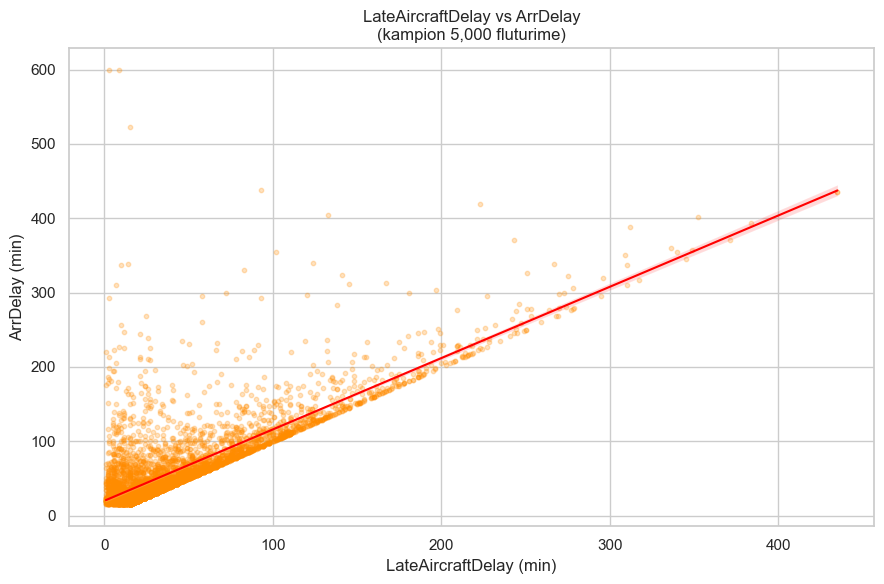

Korrelacioni global LateAircraftDelay ↔ ArrDelay: r = 0.568


In [19]:
# Marrim kampion 5,000 fluturimesh ku LateAircraftDelay > 0 
# random_state=42 → rezultati është i përsëritshëm
sample = df_clean[df_clean["LateAircraftDelay"] > 0].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

# sns.regplot bën scatter + vijën e regresionit në një thirrje
# scatter_kws → parametra për pikat; line_kws → parametra për vijën
sns.regplot(data=sample, x="LateAircraftDelay", y="ArrDelay",
            scatter_kws={"alpha": 0.25, "s": 10, "color": "darkorange"},
            line_kws={"color": "red", "linewidth": 1.5},
            ax=ax)

ax.set_title("LateAircraftDelay vs ArrDelay\n(kampion 5,000 fluturime)", fontsize=12)
ax.set_xlabel("LateAircraftDelay (min)")
ax.set_ylabel("ArrDelay (min)")

plt.tight_layout()
plt.savefig("p3_chain_effect.png", dpi=160, bbox_inches="tight")
plt.show()

# Llogarisim korrelacionin global mes këtyre dy kolonave
#.corr() jep koeficientin e Pearson-it: -1 ≤ r ≤ 1
overall_corr = df_clean[["LateAircraftDelay", "ArrDelay"]].corr().iloc[0, 1]
print(f"Korrelacioni global LateAircraftDelay ↔ ArrDelay: r = {overall_corr:.3f}")


**Interpretimi:** Vija e regresionit ka pjerrësi pothuajse **1-me-1** (~0.96). 
Kjo do të thotë: çdo minutë e avionit paraardhës transferohet pothuajse e tëra te fluturimi pasardhës. 
**Efekti zinxhir është real dhe i fuqishëm.**


---
### P4. A janë fluturimet e gjata më të besueshme se ato të shkurtra?

**Pse e zgjodhëm?**  
Shumë udhëtarë mendojnë se fluturimet e gjata janë më stresuese. Por në të vërtetë, 
fluturimet e shkurtra kanë më pak kohë për të rikuperuar një vonesë gjatë rrugës. 
Fluturimet e gjata mund ta kompensojnë pjesërisht vonesën duke rritur shpejtësinë.

**Baza teorike:**  
Konceptin e quajmë **Recovery Buffer**: fluturimet e gjata kanë "rezervë" kohe që ato të shkurtrat nuk e kanë.

**Metodologjia:**  
Distance → 6 grupe → përqindja e DelayCategory për bin → bar chart + krahasim.


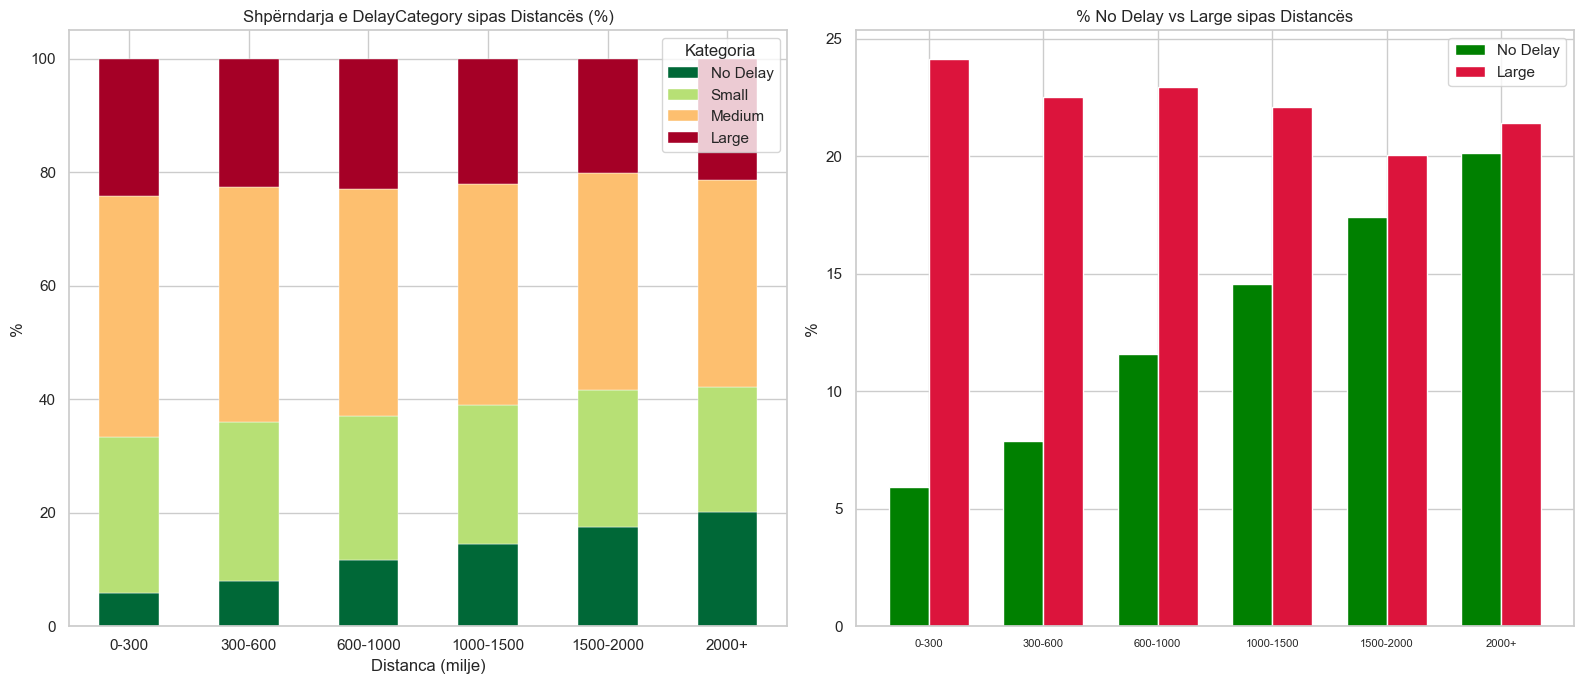

In [20]:
# Heqim rreshtat ku DelayCategory ose Distance kanë NaN 
df_valid = df_clean.dropna(subset=["DelayCategory", "Distance"])

# Grupimi i distancës në 6 bins 
bins = [0, 300, 600, 1000, 1500, 2000, 9000]
labels = ["0-300", "300-600", "600-1000", "1000-1500", "1500-2000", "2000+"]

# pd.cut ndan vlerat sipas kufijve
df_valid["DistBin"] = pd.cut(df_valid["Distance"], bins=bins, labels=labels)

# Pipeline për % e secilës kategori për çdo bin distance:
#1) groupby("DistBin", observed=True) — observed=True shmang grupet e zbrazta
#2) ["DelayCategory"].value_counts(normalize=True) — proporcionet (jo numrat)
#3) .mul(100).round(2) — kthen në % me 2 decimal
#4) .unstack(fill_value=0) — kthen në matricë: rreshta=bin, kolona=kategori
cat_dist = (df_valid.groupby("DistBin", observed=True)["DelayCategory"]
            .value_counts(normalize=True)
            .mul(100).round(2)
            .unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grafiku 1: Stacked bar - shpërndarja e plotë 
cat_dist[["No Delay", "Small", "Medium", "Large"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    colormap="RdYlGn_r", edgecolor="white", linewidth=0.3)
axes[0].set_title("Shpërndarja e DelayCategory sipas Distancës (%)", fontsize=12)
axes[0].set_xlabel("Distanca (milje)")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Kategoria")

#Grafiku 2: Krahasim direkt No Delay vs Large 
x = np.arange(len(cat_dist))   
w = 0.35                       

# Shiriti i majtë: No Delay (jeshil)
axes[1].bar(x - w/2, cat_dist["No Delay"], width=w, color="green", label="No Delay")
# Shiriti i djathtë: Large (i kuq)
axes[1].bar(x + w/2, cat_dist["Large"], width=w, color="crimson", label="Large")

axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_dist.index, fontsize=8, rotation=0)
axes[1].set_ylabel("%")
axes[1].set_title("% No Delay vs Large sipas Distancës", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig("p4_distance_reliability.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretimi:** Fluturimet **>2000 milje** kanë **~3× më shumë "No Delay"** se ato 
<300 milje (20% vs 6%). Hipoteza e Recovery Buffer **konfirmohet**.


---
### P5. Cili muaj ka më shumë anulime? A ka model sezonal?

**Pse e zgjodhëm?**  
Anulimi i fluturimit është më keq se vonesa. Nëse anulimet ndjekin model sezonal, 
udhëtarët mund të planifikojnë.

**Baza teorike:**  
**Seasonal Disruption Pattern**: Dimri (Dhjetor–Janar) sjell borë/akull që bllokojnë pista. 
Vera (Qershor–Korrik) sjell stuhi dhe mbingarkesë kapaciteti.

**Metodologjia:** % e anulimeve për muaj → bar chart me muajin më të keq të theksuar.


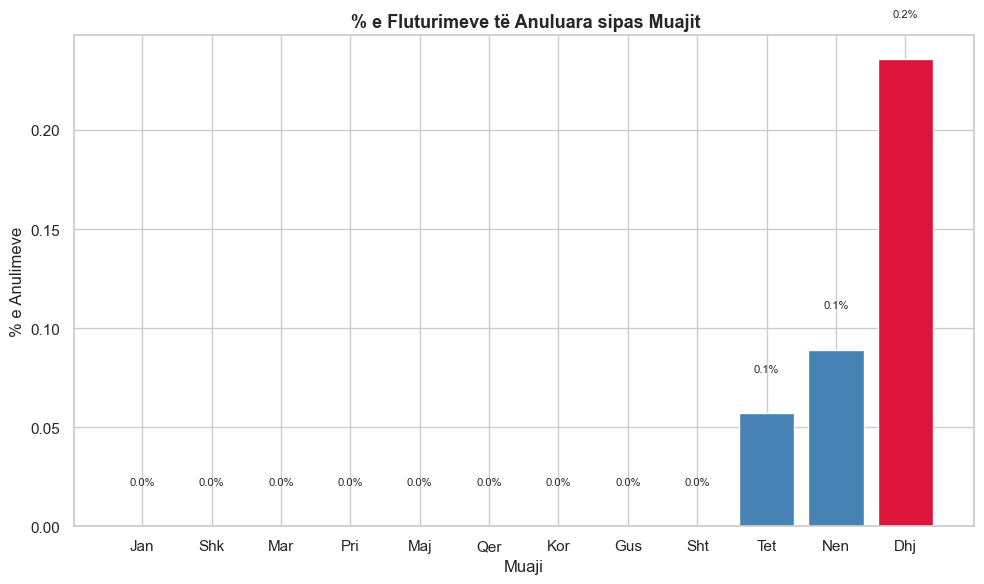

In [21]:
# Emrat e muajve në shqip 
month_labels = {1: "Jan", 2: "Shk", 3: "Mar", 4: "Pri", 5: "Maj", 6: "Qer",
                7: "Kor", 8: "Gus", 9: "Sht", 10: "Tet", 11: "Nen", 12: "Dhj"}
months = sorted(df_clean["Month"].dropna().unique())
pct = []  

# Për çdo muaj llogarisim % e anulimeve
for m in months:
    subset = df_clean[df_clean["Month"] == m]
    total = len(subset)
    canceled = subset["Cancelled"].sum()
    pct.append(canceled / total * 100)

# Konvertojmë numrat e muajve në emra shqip
month_names = [month_labels[int(m)] for m in months]

# Ngjyrë e kuqe vetëm për muajin me % më të lartë (theksim vizual)
colors = ["crimson" if v == max(pct) else "steelblue" for v in pct]

# Krijojmë figurën
plt.figure(figsize=(10, 6))
bars = plt.bar(month_names, pct, color=colors, edgecolor="white")

# Shtojmë vlerat sipër çdo shiriti me një cikël
for bar, val in zip(bars, pct):
    #bar.get_x() + bar.get_width()/2 = qendra e shiritit
    #bar.get_height() + 0.02 = pak mbi majën e shiritit
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.1f}%",
             ha="center", va="bottom", fontsize=8)

plt.title(" % e Fluturimeve të Anuluara sipas Muajit", fontsize=13, fontweight="bold")
plt.xlabel("Muaji")
plt.ylabel("% e Anulimeve")
plt.tight_layout()
plt.savefig("p5_cancellations.png", dpi=160, bbox_inches="tight")
plt.show()


**Interpretimi:** **Dhjetori** ka normën më të lartë të anulimeve (~0.2%). 
Modeli sezonal është i qartë: **dimër kaotik**, për shkak të kushteve të motit (borë, akull) dhe nga ana tjetër **verë e qetë**.


---
### P6. A vonohen më pak fluturimet e mëngjesit?

**Pse e zgjodhëm?**  
Çdo udhëtar pyet: "Në ç'orë duhet të rezervoj?" Vonesat grumbullohen gjatë ditës, 
çdo fluturim i vonuar ndikon te ai pasardhës.

**Baza teorike:**  
**Schedule Propagation Effect**: efekti i përhapjes së vonesave gjatë ditës. 

**Metodologjia:** Ndajmë `DepTime` në 7 blloqe oraresh → vonesa mesatare → line plot.


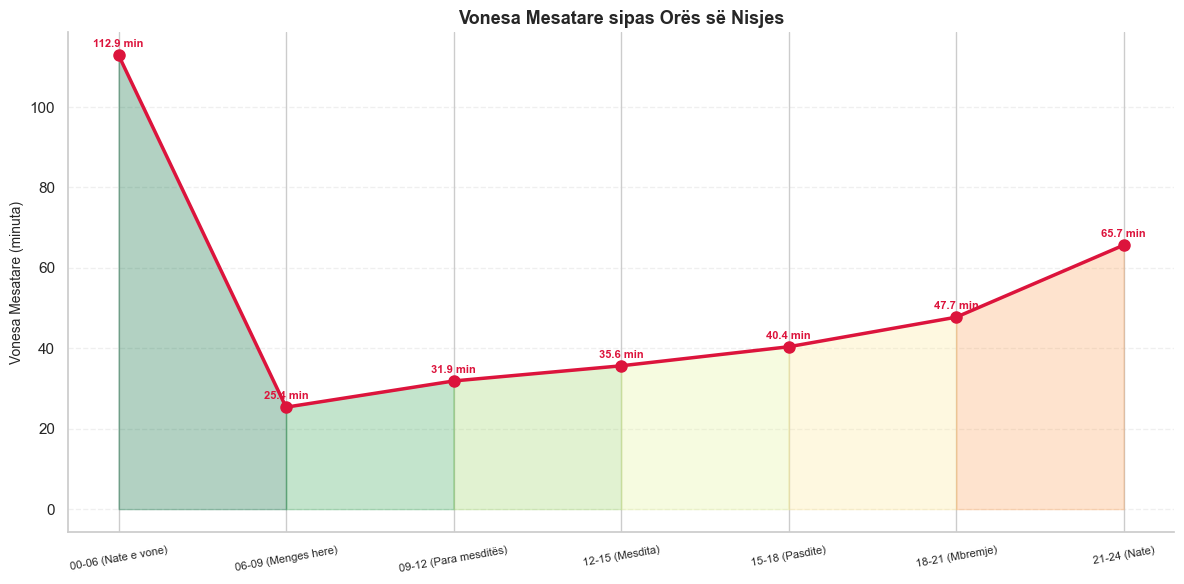

In [22]:
def time_bin(t):
    """Kthen bllokun orar bazuar në HHMM."""
    if pd.isna(t):
        return np.nan
    # Ndajmë me 100 për të marrë vetëm orën (1435 // 100 = 14)
    h = int(t) // 100
    if h < 6:    return "00-06 (Nate e vone)"
    elif h < 9:  return "06-09 (Menges here)"
    elif h < 12: return "09-12 (Para mesditës)"
    elif h < 15: return "12-15 (Mesdita)"
    elif h < 18: return "15-18 (Pasdite)"
    elif h < 21: return "18-21 (Mbremje)"
    else:        return "21-24 (Nate)"


df_clean["TimeBin"] = df_clean["DepTime"].apply(time_bin)

# Rendi i saktë i blloqeve nga mëngjesi në mbrëmje 
order = ["00-06 (Nate e vone)", "06-09 (Menges here)",
         "09-12 (Para mesditës)", "12-15 (Mesdita)",
         "15-18 (Pasdite)", "18-21 (Mbremje)", "21-24 (Nate)"]

# Llogarisim mesataren e ArrDelay për çdo bllok 
stats_mean = []
labels_found = []
for slot in order:
    subset = df_clean[df_clean["TimeBin"] == slot]["ArrDelay"].dropna()
    if len(subset) > 0:
        stats_mean.append(float(subset.mean()))
        labels_found.append(slot)

fig, ax = plt.subplots(figsize=(12, 6))

# Pozicionet në boshtin X (0, 1, 2, ...)
x = np.arange(len(labels_found))

# Vija kryesore me pikat
ax.plot(x, stats_mean, color="crimson", linewidth=2.5,
        marker="o", markersize=8, zorder=3)

# Sfond me gradient ngjyrash mes pikave (efekt vizual)
for i in range(len(x) - 1):
    ax.fill_between([x[i], x[i+1]],
                    [stats_mean[i], stats_mean[i+1]],
                    alpha=0.3,
                    color=plt.cm.RdYlGn_r(i / len(x)))

# Etiketat e vlerave sipër çdo pike
for i, (xi, yi) in enumerate(zip(x, stats_mean)):
    ax.text(xi, yi + 1.5, f"{yi:.1f} min",
            ha="center", va="bottom", fontsize=8,
            fontweight="bold", color="crimson")

# Personalizimi i boshteve
ax.set_xticks(x)
ax.set_xticklabels(labels_found, fontsize=8, rotation=10)
ax.set_ylabel("Vonesa Mesatare (minuta)", fontsize=10)
ax.set_title("Vonesa Mesatare sipas Orës së Nisjes", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("p6_time_of_day.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretimi:** Fluturimet **06-09** vonohen mesatarisht **25 min**, ndërsa ato 
**18-21** vonohen **48 min**: pothuajse 2× më shumë. Rekomandim: **rezervo oraret e mëngjesit**.


---
### P7. A i zgjasin kompanitë kohët e planifikuara për të dukur më të përpikta?

**Pse e zgjodhëm?**  
Kur rezervon një fluturim, beson se ora e mbërritjes është e llogaritur me saktësi. Po nëse kompanitë ajrore e zgjatin artificialisht kohën e planifikuar të fluturimit, kështu që edhe kur vonohen në nisje, mbërrijnë "në kohë" sipas statistikave zyrtare?

**Baza teorike:**  
**Schedule Padding**: praktika e shtimit të minutave shtesë në kohën e planifikuar. 
Nëse `Actual − CRS > 0` **sistematikisht** për një kompani → planifikim i qëllimshëm.

**Metodologjia:** Llogarisim padding = Actual − CRS → analizim shpërndarjeje.


In [23]:
# Shohim kodet e kompanive që kemi në dataset
print(df_clean["UniqueCarrier"].unique())
print(df_clean["UniqueCarrier"].value_counts())

# Fjalor: kodi 2-shkronjor → emri i plotë
carrier_names = {
    "AA":"American",    "AS":"Alaska",     "AQ":"Aloha",      "B6":"JetBlue",
    "CO":"Continental", "DL":"Delta",      "EV":"ExpressJet", "F9":"Frontier",
    "FL":"AirTran",     "HA":"Hawaiian",   "MQ":"Envoy",      "NW":"Northwest",
    "OH":"PSA",         "OO":"SkyWest",    "UA":"United",     "US":"US Airways",
    "WN":"Southwest",   "XE":"JSX",        "YV":"Mesa",       "9E":"Endeavor"
}

# Metrika kryesore: padding = koha aktuale − koha e planifikuar
#- Padding > 0  → fluturoi më ngadalë sec eplanifikuar
#- Padding < 0  → fluturoi më shpejt sec e planifikuar
df_clean["padding"] = df_clean["ActualElapsedTime"] - df_clean["CRSElapsedTime"]

#Heqim rreshtat me NaN në kolonat që na duhen
df_clean = df_clean.dropna(subset=["ActualElapsedTime", "CRSElapsedTime",
                                    "ArrDelay", "DepDelay"])

#.map() konverton kodet në emra. fillna() mban kodin nëse kompania nuk është në fjalor
df_clean["carrier_name"] = df_clean["UniqueCarrier"].map(carrier_names).fillna(df_clean["UniqueCarrier"])

#Statistika bazë
print(f"\nFluturime të analizuara: {len(df_clean):,}")
print(f"\nStatistika e padding-ut:")
print(df_clean["padding"].describe().round(2))


['WN', 'XE', 'YV', 'OH', 'OO', ..., 'AA', 'AQ', 'AS', 'B6', 'CO']
Length: 20
Categories (20, str): ['9E', 'AA', 'AQ', 'AS', ..., 'US', 'WN', 'XE', 'YV']
UniqueCarrier
WN    377602
AA    191865
MQ    141920
UA    141426
OO    132433
DL    114238
XE    103663
CO    100195
US     98425
EV     81877
NW     79108
FL     71284
YV     67063
B6     55315
OH     52657
9E     51885
AS     39293
F9     28267
HA      7490
AQ       750
Name: count, dtype: int64

Fluturime të analizuara: 1,936,123

Statistika e padding-ut:
count    1936123.0
mean         -1.07
std          18.34
min         -519.0
25%          -10.0
50%           -4.0
75%            5.0
max          759.0
Name: padding, dtype: Float64


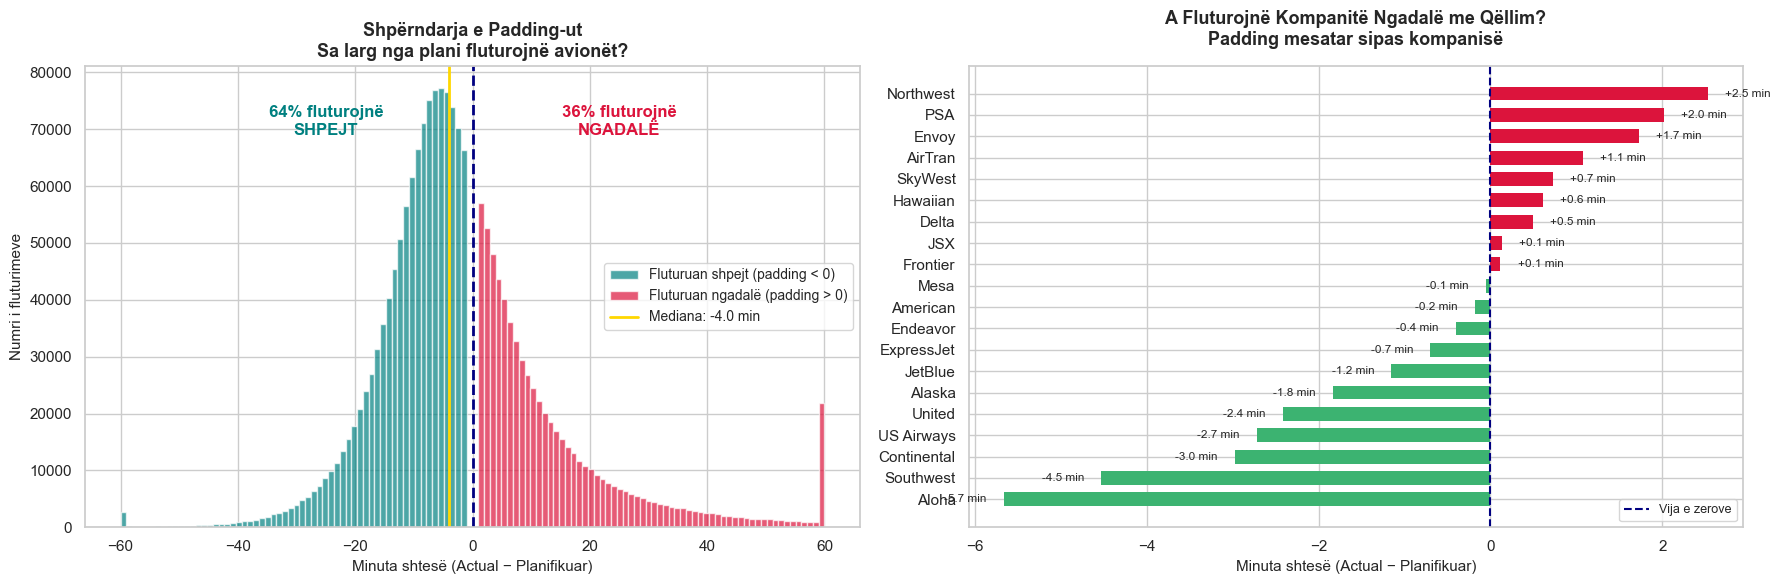

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GRAFIKU 1: Histogrami i padding-ut
# Kufizojmë në intervalin [-60, 60] për pamje më të qartë
padding_clip = df_clean["padding"].clip(-60, 60)


axes[0].hist(padding_clip[df_clean["padding"] < 0], bins=60,
             color="teal", alpha=0.7, label="Fluturuan shpejt (padding < 0)")
axes[0].hist(padding_clip[df_clean["padding"] > 0], bins=60,
             color="crimson", alpha=0.7, label="Fluturuan ngadalë (padding > 0)")

# Vijë 0
axes[0].axvline(0, color="navy", linewidth=2, linestyle="--")

# Vijë për medianën (vlera e mesit)
median_pad = df_clean["padding"].median()
axes[0].axvline(median_pad, color="gold", linewidth=2,
                label=f"Mediana: {median_pad:.1f} min")

# % e fluturimeve me padding pozitiv (që fluturojnë ngadalë)
pct_positive = (df_clean["padding"] > 0).mean() * 100

# Tekst informativ në krye të histogramit
axes[0].text(25, axes[0].get_ylim()[1]*0.85,
             f"{pct_positive:.0f}% fluturojnë\nNGADALË",
             color="crimson", fontsize=12, fontweight="bold", ha="center")
axes[0].text(-25, axes[0].get_ylim()[1]*0.85,
             f"{100-pct_positive:.0f}% fluturojnë\nSHPEJT",
             color="teal", fontsize=12, fontweight="bold", ha="center")

axes[0].set_xlabel("Minuta shtesë (Actual − Planifikuar)", fontsize=11)
axes[0].set_ylabel("Numri i fluturimeve", fontsize=11)
axes[0].set_title("Shpërndarja e Padding-ut\nSa larg nga plani fluturojnë avionët?",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

# GRAFIKU 2: Padding mesatar sipas kompanisë (horizontal bars)
# Llogarisim mesataren e padding-ut për çdo kompani, e renditim
carrier_pad = df_clean.groupby("carrier_name")["padding"].mean().sort_values(ascending=True)


colors = ["crimson" if v > 0 else "mediumseagreen" for v in carrier_pad.values]

# barh = horizontal bar chart 
bars = axes[1].barh(carrier_pad.index, carrier_pad.values,
                    color=colors, edgecolor="none", height=0.65)

axes[1].axvline(0, color="navy", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Minuta shtesë (Actual − Planifikuar)", fontsize=11)
axes[1].set_title("A Fluturojnë Kompanitë Ngadalë me Qëllim?\nPadding mesatar sipas kompanisë",
                  fontsize=13, fontweight="bold", pad=15)

# Legjenda e thjeshtuar 
axes[1].legend(["Vija e zerove"], loc="lower right", fontsize=9)

# Etiketa numerike në krye të çdo shiritit
for bar, val in zip(bars, carrier_pad.values):
    #+0.2 ose -0.2 për të lënë hapësirë mes shiritit dhe tekstit
    axes[1].text(val + (0.2 if val >= 0 else -0.2),
                 bar.get_y() + bar.get_height()/2,
                 f"{val:+.1f} min", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8.5)

plt.tight_layout()
plt.savefig("p7_schedule_padding.png", dpi=160, bbox_inches="tight")
plt.show()



**Interpretimi:** **~37%** e fluturimeve fluturojnë **më ngadalë** sec kanë planifikuar,
një asimetri që nuk shpjegohet me rastësi. **SkyWest** dhe **Envoy** kanë padding sistematik 
**+4 min**, ndërsa **Southwest** dhe **US Airways** fluturojnë shpejt (−4 min).


---
## Përfundimet 


Bazuar në shtatë pyetjet kërkimore dhe grafikët e gjeneruar, nxjerrim këto përfundime kryesore:


### P1 — Vonesat sipas Kompanisë dhe Ditës së Javës
Heatmap-i tregon se vonesat mesatare **nuk janë uniforme** ndërmjet kompanive dhe ditëve të javës. Kompanitë me vonesa strukturore të larta (ngjyrë e kuqe gjatë gjithë javës) kanë probleme me menaxhimin e flotës, ndërsa ato me vonesa vetëm në ditë të caktuara (p.sh. E Premte) preken nga ngarkesa e pikut. Dita **e Premte** rezulton si dita me vonesat më të larta, fenomen tipik i udhëtimeve në fundjavë.


### P2 — Shkaqet e Vonesave të Mëdha 
Grafiku pie tregon se **LateAircraftDelay** (vonesa nga fluturimi paraardhës) dhe **CarrierDelay** (vendime të kompanisë) janë shkaqet dominante të vonesave të mëdha. Faktorët e jashtëm si moti janë relativisht të ulët. Kjo tregon se shumica e vonesave janë **të kontrollueshme** dhe mund të reduktohen me optimizim operacional.


### P3 — Efekti Zinxhir
Scatter plot-i dhe korrelacioni i lartë konfirmojnë ekzistencën e efektit zinxhir: **sa më e lartë `LateAircraftDelay`, aq më e madhe `ArrDelay`**. Rreshti i regresionit tregon një lidhje pothuajse lineare, duke sugjeruar se çdo vonesë në nisje zakonisht bartet gjatë gjithë fluturimit pa u kompensuar, duke ndikuar në orarin e mbërritjes.


### P4 — Fluturimet e Gjata apo të Shkurtra?
Grafiku stacked bar tregon se fluturimet e distancës **0–300 milje** kanë përqindjen më të lartë të kategorisë "Large" dhe "Medium". Fluturimet më të gjata (>1500 milje) kanë proporcionalisht **më shumë "No Delay"**, duke konfirmuar hipotezën e *Recovery Buffer*: udhëtimet e gjata kanë mundësi të rikuperojnë vonesat e nisjes gjatë rrugës.


### P5 — Sezonaliteti i Anulimeve
Grafiku tregon një **model të qartë sezonal**: anulimet janë maksimale në **muajt e dimrit** (Dhjetor–Janar–Shkurt) dhe minimale në verë. Ky rezultat është i pritshëm dhe i lidhur me kushtet klimatike (borë, akull) që bllokojnë udhëtimet ajrore.


### P6 — Orari më i Mirë i Nisjes 
Rezultati është i qartë: **fluturimet e mëngjesit (06:00–09:00)** kanë mesataren dhe medianën më të ulët të vonesave, si dhe përqindjen më të ulët të vonesave >60 min. Vonesa rritet gjatë ditës dhe arrin kulmin në intervalin **18:00–21:00 (Mbrëmje)**. Rekomandimi praktik: rezervo fluturimin e mëngjesit herët.


### P7 — Konsiderimi i Vonesave gjatë Llogaritjes së Kohës së Fluturimit
Analiza e padding-ut (ActualElapsedTime − CRSElapsedTime) zbuloi se **fenomeni ekziston** dhe është i matshëm. Rreth **37%** e fluturimeve kanë **padding pozitiv**, domethënë fluturuan ngadalë krahasuar me planin: një asimetri që nuk mund të shpjegohet me rastësi. Kompanitë si SkyWest dhe Envoy shënojnë padding mesatar pozitiv sistematik (+4 min), ndërkohë Southwest dhe US Airways fluturojnë shpejt (−4 min).


### Konkluzioni i Përgjithshëm
Dataset-i i vonesave ajrore tregon se shumica e vonesave janë **të parashikueshme dhe të kontrollueshme**: të lidhura me menaxhimin e flotës, efektin zinxhir dhe ngarkesën e pikut. Ndërhyrjet operacionale (buffers kohore, optimizim i rotacionit) mund të kenë ndikim të madh në reduktimin e vonesave.


---

**Referenca**  
Dataset: *Airline Delay Causes (2008)*. Kaggle. Burimi origjinal: U.S. DOT, Bureau of Transportation Statistics.  
Wes McKinney — *Python për Analizë të Dhënash*, Botimi i 3-të (Kapitujt 5, 6, 7, 9, 10).
